In [1]:
import os

REPO_DIR = "propaganda-detector"
if not os.path.exists(REPO_DIR):
    print("📥 Cloning repository...")
    !git clone https://github.com/Hannysia/propaganda-detector.git
else:
    print("🔄 Updating repository...")
    %cd {REPO_DIR}
    !git pull
    %cd ..

print("📦 Installing dependencies...")
!pip install -r {REPO_DIR}/requirements.txt -q
!python -m spacy download en_core_web_trf -q

📥 Cloning repository...
Cloning into 'propaganda-detector'...
remote: Enumerating objects: 243, done.
remote: Counting objects: 100% (243/243), done.
remote: Compressing objects: 100% (158/158), done.
remote: Total 243 (delta 133), reused 180 (delta 70), pack-reused 0 (from 0)
Receiving objects: 100% (243/243), 546.85 KiB | 16.57 MiB/s, done.
Resolving deltas: 100% (133/133), done.
📦 Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 85.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 108.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 132.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 125.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 98.7 MB/s eta

In [ ]:
import os
os._exit(00)

In [1]:
import os
import sys
import gc
import torch
from kaggle_secrets import UserSecretsClient

# --- 1. SECRETS ---
print("🔑 Setting up environment variables...")
try:
    user_secrets = UserSecretsClient()
    os.environ["HF_TOKEN"] = user_secrets.get_secret("HF_TOKEN")
    os.environ["WANDB_API_KEY"] = user_secrets.get_secret("WANDB_API_KEY")
    
    import wandb
    wandb.login(key=os.environ["WANDB_API_KEY"])
    print("✅ Secrets loaded & W&B logged in.")
except Exception as e:
    print(f"⚠️ Secrets Warning: {e}")

# --- 2. NAVIGATE TO REPO ---
REPO_DIR = "propaganda-detector"

if os.getcwd().split('/')[-1] != REPO_DIR:
    if os.path.exists(REPO_DIR):
        %cd {REPO_DIR}
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ Launch Cell No. 1!")

sys.path.append(os.getcwd())

# --- 3. CLEANUP FUNCTION ---
def clear_gpu_memory():
    print("🧹 Cleaning GPU memory...")
    gc.collect()
    torch.cuda.empty_cache()
    print("✨ GPU memory cleared!")
    


🔑 Setting up environment variables...


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

✅ Secrets loaded & W&B logged in.
/kaggle/working/propaganda-detector
📂 Changed directory to: /kaggle/working/propaganda-detector


### **1: RoBERTa-Large**

In [2]:
from src.train import run_cv_pipeline

print("\n🚀 STARTING EXPERIMENT 1: RoBERTa-Large")

try:
    run_cv_pipeline(
        model_name="roberta-base",
        source_dataset_repo="hannusia123123/propaganda-detector-dataset",
        hf_model_repo="hannusia123123/propaganda-roberta-base",
        hf_oof_dataset_repo="hannusia123123/propaganda-detector-dataset",
        run_prefix="roberta-base",
        
        batch_size=16,
        gradient_accumulation_steps=1,
        learning_rate=2e-5,
        num_train_epochs=8,
        warmup_ratio=0.1,
        weight_decay=0.1,
    )
    
    clear_gpu_memory()

except Exception as e:
    print(f"❌ Error in Experiment 1: {e}")

2026-01-13 18:05:07.298896: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768327507.488433      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768327507.543152      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Fold 4 saved to branch 'fold-4'
📉 Fold 4 F1 Macro: 0.4840


eval/accuracy,▁▆▇▇██
eval/f1_macro,▁▅▇███
eval/loss,█▃▃▁▃▃
eval/precision_macro,▁▅▇███
eval/recall_macro,▁▅▆█▇▇
eval/runtime,▂▃▁▂▇█
eval/samples_per_second,▇▆█▇▂▁
eval/steps_per_second,▇▆█▇▂▁
final_f1_macro,▁
test/accuracy,▁█▁
test/f1_macro,▁█▁


Cleaning up disk space for Fold 4...
✅ Deleted local checkpoint: ./results/fold4

💾 Saving Final Datasets & Metadata...
☁️ Uploading artifacts to HF Dataset: hannusia123123/propaganda-detector-dataset
✅ SUCCESS! All files uploaded to HF.

 Validating Ensemble (Average of 5 folds) on Holdout Set...
🔥 FINAL HOLDOUT F1 SCORE (Ensemble): 0.5808
------------------------------
                                    precision    recall  f1-score   support

               Appeal_to_Authority     0.5789    0.7857    0.6667        14
          Appeal_to_fear-prejudice     0.5294    0.6207    0.5714        29
    Bandwagon,Reductio_ad_hitlerum     0.6000    0.3750    0.4615         8
           Black-and-White_Fallacy     0.5455    0.5455    0.5455        11
         Causal_Oversimplification     0.4500    0.4286    0.4390        21
                             Doubt     0.6667    0.5714    0.6154        49
         Exaggeration,Minimisation     0.4706    0.6957    0.5614        46
                 

### **2: DeBERTa-v3-Base**

In [3]:
print("\n🚀 STARTING EXPERIMENT 2: DeBERTa-v3-Base")

try:
    clear_gpu_memory() 
    
    run_cv_pipeline(
        model_name="microsoft/deberta-v3-base",     
        
        hf_model_repo="hannusia123123/propaganda-deberta-v3-base", 
        hf_oof_dataset_repo="hannusia123123/propaganda-detector-dataset",
        run_prefix="deberta-v3-base",
        source_dataset_repo="hannusia123123/propaganda-detector-dataset",
        
        batch_size=8,                  
        gradient_accumulation_steps=2, 
        learning_rate=2e-5,
        num_train_epochs=10,
        warmup_ratio=0.1,
        weight_decay=0.1,             
    )
    
    clear_gpu_memory()

except Exception as e:
    print(f"❌ Error in Experiment: {e}")


🚀 STARTING EXPERIMENT 2: DeBERTa-v3-Base
🧹 Cleaning GPU memory...
✨ GPU memory cleared!
Seed set to 42
🚀 STARTING PIPELINE: deberta-v3-base-2026-01-13_19-30
☁️ Downloading data from Hugging Face: hannusia123123/propaganda-detector-dataset


Generating train split:   0%|          | 0/6128 [00:00<?, ? examples/s]

📊 Data Split (Loaded from file): Main=5515, Holdout=613

📊 --- HOLDOUT SET Set Statistics ---
Articles: 36 unique articles
Sentences: 613 total sentences
                                    Count  Percent %
label                                               
Loaded_Language                       212      34.58
Name_Calling,Labeling                 106      17.29
Repetition                             62      10.11
Doubt                                  49       7.99
Exaggeration,Minimisation              46       7.50
Appeal_to_fear-prejudice               29       4.73
Flag-Waving                            23       3.75
Causal_Oversimplification              21       3.43
Appeal_to_Authority                    14       2.28
Slogans                                13       2.12
Black-and-White_Fallacy                11       1.79
Whataboutism,Straw_Men,Red_Herring     11       1.79
Bandwagon,Reductio_ad_hitlerum          8       1.31
Thought-terminating_Cliches             8       1.3

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

...

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Fold 4 saved to branch 'fold-4'
📉 Fold 4 F1 Macro: 0.4650


eval/accuracy,▁▄▆▇▇████
eval/f1_macro,▁▄▆▇▇████
eval/loss,█▅▂▁▁▃▂▂▃
eval/precision_macro,▁▄▆▇▇████
eval/recall_macro,▁▄▆██▇███
eval/runtime,▁▄▄▃▅▇█▄▁
eval/samples_per_second,█▅▅▆▄▂▁▅█
eval/steps_per_second,█▅▅▆▄▂▁▅█
final_f1_macro,▁
test/accuracy,▁█▁
test/f1_macro,▁█▁


Cleaning up disk space for Fold 4...
✅ Deleted local checkpoint: ./results/fold4

💾 Saving Final Datasets & Metadata...
☁️ Uploading artifacts to HF Dataset: hannusia123123/propaganda-detector-dataset
✅ SUCCESS! All files uploaded to HF.

 Validating Ensemble (Average of 5 folds) on Holdout Set...
🔥 FINAL HOLDOUT F1 SCORE (Ensemble): 0.5880
------------------------------
                                    precision    recall  f1-score   support

               Appeal_to_Authority     0.5263    0.7143    0.6061        14
          Appeal_to_fear-prejudice     0.4667    0.4828    0.4746        29
    Bandwagon,Reductio_ad_hitlerum     0.6250    0.6250    0.6250         8
           Black-and-White_Fallacy     0.5556    0.4545    0.5000        11
         Causal_Oversimplification     0.5000    0.4286    0.4615        21
                             Doubt     0.7143    0.7143    0.7143        49
         Exaggeration,Minimisation     0.4364    0.5217    0.4752        46
                 

### **3: XLNet-Base-Cased**

In [2]:
from src.train import run_cv_pipeline

print("\n🚀 STARTING EXPERIMENT 3: XLNet-Base-Cased")

try:
    clear_gpu_memory() 
    
    run_cv_pipeline(
        model_name="xlnet-base-cased",     
        
        hf_model_repo="hannusia123123/propaganda-xlnet-base", 
        hf_oof_dataset_repo="hannusia123123/propaganda-detector-dataset",
        run_prefix="xlnet-base",
        source_dataset_repo="hannusia123123/propaganda-detector-dataset",
        
        batch_size=8,                  
        gradient_accumulation_steps=2,
        
        learning_rate=2e-5,            
        num_train_epochs=10,            
        
        warmup_ratio=0.1,
        weight_decay=0.01,        
    )
    
    clear_gpu_memory()

except Exception as e:
    print(f"❌ Error in Experiment: {e}")

2026-01-14 09:30:42.230887: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768383042.569689     182 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768383042.665086     182 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768383043.591281     182 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768383043.591336     182 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768383043.591339     182 computation_placer.cc:177] computation placer alr


🚀 STARTING EXPERIMENT 3: XLNet-Base-Cased
✨ GPU memory cleared!
Seed set to 42
🚀 STARTING PIPELINE: xlnet-base-2026-01-14_09-31
☁️ Downloading data from Hugging Face: hannusia123123/propaganda-detector-dataset


README.md:   0%|          | 0.00/538 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/808k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6128 [00:00<?, ? examples/s]

...

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Fold 4 saved to branch 'fold-4'
📉 Fold 4 F1 Macro: 0.4752


eval/accuracy,▁▅▆▆▆█▇███
eval/f1_macro,▁▅▆▇▇▇████
eval/loss,█▃▂▁▂▃▃▄▅▅
eval/precision_macro,▁▃▅▅▆▇▇▇██
eval/recall_macro,▁▆▆█▇███▇█
eval/runtime,▂▂▄▄▄▄▄█▁▇
eval/samples_per_second,▆▆▅▅▅▄▅▁█▂
eval/steps_per_second,▆▆▅▅▅▄▅▁█▂
final_f1_macro,▁
test/accuracy,▁█▁
+12,...


Cleaning up disk space for Fold 4...
✅ Deleted local checkpoint: ./results/fold4

💾 Saving Final Datasets & Metadata...
☁️ Uploading artifacts to HF Dataset: hannusia123123/propaganda-detector-dataset
✅ SUCCESS! All files uploaded to HF.

 Validating Ensemble (Average of 5 folds) on Holdout Set...
🔥 FINAL HOLDOUT F1 SCORE (Ensemble): 0.5618
------------------------------
                                    precision    recall  f1-score   support

               Appeal_to_Authority     0.5238    0.7857    0.6286        14
          Appeal_to_fear-prejudice     0.4615    0.6207    0.5294        29
    Bandwagon,Reductio_ad_hitlerum     0.5714    0.5000    0.5333         8
           Black-and-White_Fallacy     0.5000    0.2727    0.3529        11
         Causal_Oversimplification     0.4444    0.5714    0.5000        21
                             Doubt     0.5686    0.5918    0.5800        49
         Exaggeration,Minimisation     0.4407    0.5652    0.4952        46
                 

### **4: Toxic-BERT**

In [4]:
print("\n🚀 STARTING EXPERIMENT 4: Toxic-BERT")

try:
    clear_gpu_memory() 
    
    run_cv_pipeline(
        model_name="unitary/toxic-bert",     
        
        source_dataset_repo="hannusia123123/propaganda-detector-dataset",
        hf_model_repo="hannusia123123/propaganda-toxic-bert", 
        hf_oof_dataset_repo="hannusia123123/propaganda-detector-dataset",
        run_prefix="toxic-bert",
        
        batch_size=8,                  
        gradient_accumulation_steps=2,
        
        learning_rate=1e-5,
        num_train_epochs=10,            
        
        warmup_ratio=0.1,
        weight_decay=0.1,
    )
    
    clear_gpu_memory()

except Exception as e:
    print(f"❌ Error in Experiment: {e}")


🚀 STARTING EXPERIMENT 4: Toxic-BERT
✨ GPU memory cleared!
Seed set to 42
🚀 STARTING PIPELINE: toxic-bert-2026-01-14_11-50
☁️ Downloading data from Hugging Face: hannusia123123/propaganda-detector-dataset
📊 Data Split (Loaded from file): Main=5515, Holdout=613

📊 --- HOLDOUT SET Set Statistics ---
Articles: 36 unique articles
Sentences: 613 total sentences
                                    Count  Percent %
label                                               
Loaded_Language                       212      34.58
Name_Calling,Labeling                 106      17.29
Repetition                             62      10.11
Doubt                                  49       7.99
Exaggeration,Minimisation              46       7.50
Appeal_to_fear-prejudice               29       4.73
Flag-Waving                            23       3.75
Causal_Oversimplification              21       3.43
Appeal_to_Authority                    14       2.28
Slogans                                13       2.12
Black

eval/accuracy,▁██
eval/f1_macro,▁▆█
eval/loss,█▄▁
eval/precision_macro,▁▇█
eval/recall_macro,▁▅█
eval/runtime,▁▄█
eval/samples_per_second,█▅▁
eval/steps_per_second,█▅▁
train/epoch,▁▃▄▆█
train/global_step,▁▃▄▆█
+3,...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at unitary/toxic-bert and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([6]) in the checkpoint and torch.Size([14]) in the model instantiated
- classifier.weight: found shape torch.Size([6, 768]) in the checkpoint and torch.Size([14, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/kaggle/working/propaganda-detector/src/models/trainer.py:7: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedLossTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


🚀 Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,No log,2.607861,0.094288,0.045710,0.076788,0.085724
2,2.608100,2.447181,0.281052,0.157298,0.225991,0.175953
3,2.608100,2.297761,0.273799,0.169194,0.168862,0.226518
4,2.223200,2.181200,0.333636,0.210583,0.201119,0.253059
5,2.223200,2.095230,0.355394,0.259766,0.240198,0.322936
6,1.786900,2.061826,0.350861,0.260048,0.250161,0.306463
7,1.786900,2.015938,0.378966,0.285896,0.264317,0.341319
8,1.437200,2.014783,0.387126,0.301305,0.281412,0.364386
9,1.437200,1.999002,0.391659,0.299229,0.281915,0.351396
10,1.185700,1.988037,0.395286,0.305366,0.285515,0.356158


...

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Fold 4 saved to branch 'fold-4'
📉 Fold 4 F1 Macro: 0.3241


eval/accuracy,▁▂▄▄▆▆▇███
eval/f1_macro,▁▃▄▅▆▇████
eval/loss,█▆▄▃▂▂▁▁▁▁
eval/precision_macro,▁▅▅▆▆▇████
eval/recall_macro,▁▃▄▆▇▇████
eval/runtime,▁▃▁█▁▃█▃▃▄
eval/samples_per_second,█▆█▁█▆▁▆▆▅
eval/steps_per_second,█▆█▁█▆▁▆▆▅
final_f1_macro,▁
test/accuracy,▁█▁
+12,...


Cleaning up disk space for Fold 4...
✅ Deleted local checkpoint: ./results/fold4

💾 Saving Final Datasets & Metadata...
☁️ Uploading artifacts to HF Dataset: hannusia123123/propaganda-detector-dataset
✅ SUCCESS! All files uploaded to HF.

 Validating Ensemble (Average of 5 folds) on Holdout Set...
🔥 FINAL HOLDOUT F1 SCORE (Ensemble): 0.3916
------------------------------
                                    precision    recall  f1-score   support

               Appeal_to_Authority     0.3000    0.6429    0.4091        14
          Appeal_to_fear-prejudice     0.3333    0.4483    0.3824        29
    Bandwagon,Reductio_ad_hitlerum     0.4000    0.5000    0.4444         8
           Black-and-White_Fallacy     0.1250    0.0909    0.1053        11
         Causal_Oversimplification     0.2051    0.3810    0.2667        21
                             Doubt     0.4286    0.4898    0.4571        49
         Exaggeration,Minimisation     0.3000    0.2609    0.2791        46
                 

In [ ]:
import os
os._exit(00)

In [3]:
%%writefile src/train_stacking.py
import os
import pandas as pd
import numpy as np
import json
import optuna
import shutil

from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report
from huggingface_hub import HfApi, hf_hub_download
optuna.logging.set_verbosity(optuna.logging.WARNING)

try:
    import catboost
    import optuna
except ImportError:
    os.system("pip install catboost optuna -q")
    from catboost import CatBoostClassifier
    import optuna

BASE_MODELS = [
    "roberta-base",
    "microsoft/deberta-v3-base",
    "xlnet-base-cased",
    "unitary/toxic-bert"
]

HF_DATASET_REPO = "hannusia123123/propaganda-detector-dataset"
HF_STACKING_REPO = "hannusia123123/propaganda-stacking-catboost"
HF_TOKEN = os.getenv("HF_TOKEN")

class PropagandaStacker:
    def __init__(self):
        self.api = HfApi()
        self.le = LabelEncoder()
        
    def load_and_merge(self, prefix="oof"):
        print(f"\nDownloading & Merging {prefix.upper()} predictions...")
        merged_df = None
        
        logit_cols = [f"logit_{i}" for i in range(14)]
        
        base_merge_keys = ['article_id', 'start_offset', 'true_label']
        
        for model_name in BASE_MODELS:
            safe_name = model_name.replace("/", "-")
            filename = f"{prefix}_{safe_name}.csv"
            
            try:
                path = hf_hub_download(
                    repo_id=HF_DATASET_REPO, 
                    filename=filename, 
                    repo_type="dataset",
                    token=HF_TOKEN
                )
                df = pd.read_csv(path)
                
                merge_keys = base_merge_keys.copy()
                if 'fold' in df.columns:
                    merge_keys.append('fold')

                cols_to_use = merge_keys + logit_cols
                df_subset = df[cols_to_use].copy()
                
                rename_map = {col: f"{safe_name}_{col}" for col in logit_cols}
                df_subset = df_subset.rename(columns=rename_map)
                
                if merged_df is None:
                    merged_df = df_subset
                else:
                    common_keys = [k for k in merge_keys if k in merged_df.columns]
                    merged_df = merged_df.merge(df_subset, on=common_keys)
                    
                print(f"  ✅ Loaded {safe_name} ({len(df)} rows)")
                
            except Exception as e:
                print(f"❌ Failed to load {model_name}: {e}")
                raise e
        
        return merged_df

    def prepare_data(self, df):
        feature_cols = [c for c in df.columns if "logit" in c]
        
        X = df[feature_cols]
        try:
            y = self.le.transform(df['true_label'])
        except:
            y = self.le.fit_transform(df['true_label'])
            
        return X, y, feature_cols

    def find_best_params(self, X, y, n_trials=15, search_space=None):

        print(f"\nStarting Optuna Tuning ({n_trials} trials)...")
        
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, 
            test_size=0.2,
            random_state=42,
            stratify=y,
            shuffle=True
        )

        def objective(trial):
            if search_space is None:
                params = {
                    'iterations': trial.suggest_int('iterations', 500, 1500),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
                    'depth': trial.suggest_int('depth', 4, 8),
                    'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
                    'random_strength': trial.suggest_float('random_strength', 1e-9, 10),
                }
            else:
                params = search_space(trial)

            fixed_params = {
                'loss_function': 'MultiClass',
                'eval_metric': 'TotalF1',
                'random_seed': 42,
                'verbose': False,
                'allow_writing_files': False,
                'auto_class_weights': 'Balanced'
            }
            params.update(fixed_params)
            
            model = CatBoostClassifier(**params)
            model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
            
            preds = model.predict(X_val)
            return f1_score(y_val, preds, average='macro')

        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=n_trials)
        
        print(f"🎉 Best Params: {study.best_params}")
        return study.best_params
    

    def train_final_model(self, X_train, y_train, X_val, y_val, params=None):
        print("\n🚀 Training Final Stacking Model...")
        
        final_params = {
            'iterations': 1000,
            'learning_rate': 0.03,
            'depth': 6,
            'loss_function': 'MultiClass',
            'eval_metric': 'TotalF1',
            'random_seed': 42,
            'auto_class_weights': 'Balanced',
            'verbose': 100
        }
        
        if params:
            final_params.update(params)
        
        model = CatBoostClassifier(**final_params)
        
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            early_stopping_rounds=100
        )
        
        return model

    def evaluate_and_save(self, model, X_test, y_test):
        print("\nFINAL HOLDOUT RESULTS:")
        class_names = list(self.le.classes_)
        
        final_preds = model.predict(X_test)
        
        print(classification_report(y_test, final_preds, target_names=class_names, digits=4))
        f1 = f1_score(y_test, final_preds, average='macro')
        print(f"FINAL ENSEMBLE F1: {f1:.4f}")

        print("\nSaving artifacts...")
        os.makedirs("stacking_artifacts", exist_ok=True)
        model.save_model("stacking_artifacts/catboost.cbm")
        
        with open("stacking_artifacts/labels.json", "w") as f:
            json.dump(class_names, f)
            
        if HF_TOKEN:
            try:
                self.api.create_repo(repo_id=HF_STACKING_REPO, exist_ok=True)
                self.api.upload_folder(
                    folder_path="stacking_artifacts",
                    repo_id=HF_STACKING_REPO,
                    repo_type="model",
                    commit_message=f"CatBoost Ensemble F1={f1:.4f}"
                )
                print("✅ Uploaded to Hugging Face!")
            except Exception as e:
                print(f"⚠️ Upload failed: {e}")


Overwriting src/train_stacking.py


In [4]:
import sys
import importlib
import src.train_stacking
importlib.reload(src.train_stacking)

<module 'src.train_stacking' from '/kaggle/working/propaganda-detector/src/train_stacking.py'>

In [5]:
from src.train_stacking import PropagandaStacker

stacker = PropagandaStacker()

print("Loading OOF & Holdout Data...")
train_df = stacker.load_and_merge("oof")
test_df = stacker.load_and_merge("holdout")

X_train, y_train, _ = stacker.prepare_data(train_df)
X_test, y_test, _ = stacker.prepare_data(test_df)

def scientific_search_space(trial):
    return {
        'iterations': trial.suggest_int('iterations', 1000, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 50, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 255)
    }

print("\n Starting Deep Research (50 trials)...")
best_params = stacker.find_best_params(
    X_train, y_train, 
    n_trials=50, 
    search_space=scientific_search_space
)

print(f"\n WINNER PARAMS: {best_params}")
final_model = stacker.train_final_model(
    X_train, y_train, 
    X_test, y_test, 
    params=best_params
)

stacker.evaluate_and_save(final_model, X_test, y_test)

Loading OOF & Holdout Data...

  ✅ Loaded roberta-base (5515 rows)
  ✅ Loaded microsoft-deberta-v3-base (5515 rows)
  ✅ Loaded xlnet-base-cased (5515 rows)
  ✅ Loaded unitary-toxic-bert (5515 rows)

  ✅ Loaded roberta-base (613 rows)
  ✅ Loaded microsoft-deberta-v3-base (613 rows)
  ✅ Loaded xlnet-base-cased (613 rows)
  ✅ Loaded unitary-toxic-bert (613 rows)

 Starting Deep Research (50 trials)...

Starting Optuna Tuning (50 trials)...
🎉 Best Params: {'iterations': 1114, 'learning_rate': 0.022674963673585694, 'depth': 5, 'l2_leaf_reg': 11.118654221207468, 'random_strength': 1.3757160338004854e-06, 'bagging_temperature': 0.9976944382790125, 'border_count': 236}

 WINNER PARAMS: {'iterations': 1114, 'learning_rate': 0.022674963673585694, 'depth': 5, 'l2_leaf_reg': 11.118654221207468, 'random_strength': 1.3757160338004854e-06, 'bagging_temperature': 0.9976944382790125, 'border_count': 236}

🚀 Training Final Stacking Model...
0:	learn: 0.2437081	test: 0.2602298	best: 0.2602298 (0)	total: 

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Uploaded to Hugging Face!


In [6]:
import sys
import importlib
import src.train_stacking
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, classification_report
from tqdm.notebook import tqdm

importlib.reload(src.train_stacking)
from src.train_stacking import PropagandaStacker

stacker = PropagandaStacker()

print("Loading OOF & Holdout Data...")
train_df = stacker.load_and_merge("oof")
test_df = stacker.load_and_merge("holdout")

X_train, y_train, _ = stacker.prepare_data(train_df)
X_test, y_test, _ = stacker.prepare_data(test_df)

RESTORED_BEST_PARAMS = {
    'iterations': 1926,
    'learning_rate': 0.03953247193491333,
    'depth': 7,
    'l2_leaf_reg': 2.0725258792544343,
    'random_strength': 3.996392676255581e-07,
    'bagging_temperature': 0.8025026139793553,
    'border_count': 211
}

final_model = stacker.train_final_model(
    X_train, y_train, 
    X_test, y_test, 
    params=RESTORED_BEST_PARAMS
)

stacker.evaluate_and_save(final_model, X_test, y_test)

Loading OOF & Holdout Data...

  ✅ Loaded roberta-base (5515 rows)
  ✅ Loaded microsoft-deberta-v3-base (5515 rows)
  ✅ Loaded xlnet-base-cased (5515 rows)
  ✅ Loaded unitary-toxic-bert (5515 rows)

  ✅ Loaded roberta-base (613 rows)
  ✅ Loaded microsoft-deberta-v3-base (613 rows)
  ✅ Loaded xlnet-base-cased (613 rows)
  ✅ Loaded unitary-toxic-bert (613 rows)

🚀 Training Final Stacking Model...
0:	learn: 0.3239179	test: 0.3391141	best: 0.3391141 (0)	total: 117ms	remaining: 3m 44s
100:	learn: 0.7155658	test: 0.6420640	best: 0.6426114 (89)	total: 11.7s	remaining: 3m 30s
200:	learn: 0.7990467	test: 0.6432041	best: 0.6486829 (135)	total: 23.1s	remaining: 3m 18s
300:	learn: 0.8492743	test: 0.6505889	best: 0.6521003 (287)	total: 34.6s	remaining: 3m 6s
400:	learn: 0.8765092	test: 0.6616432	best: 0.6619542 (366)	total: 46.2s	remaining: 2m 55s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6619542172
bestIteration = 366

Shrink model to first 367 iterations.

FINAL HOLDOUT

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Uploaded to Hugging Face!


In [6]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, classification_report
from tqdm.notebook import tqdm
from catboost import CatBoostClassifier
from huggingface_hub import hf_hub_download
from src.train_stacking import PropagandaStacker

stacker = PropagandaStacker()

train_df = stacker.load_and_merge("oof")
test_df = stacker.load_and_merge("holdout")

X_train, y_train, _ = stacker.prepare_data(train_df)
X_test, y_test, feature_cols = stacker.prepare_data(test_df)

model_path = hf_hub_download(repo_id="hannusia123123/propaganda-stacking-catboost", filename="catboost.cbm")

final_model = CatBoostClassifier()
final_model.load_model(model_path)

probs_oof = final_model.predict_proba(X_train)
probs_test = final_model.predict_proba(X_test)

y_oof = y_train
y_true_test = y_test

def optimize_thresholds(y_true, probs, class_names):
    best_weights = [1.0] * len(class_names)
    
    base_preds = np.argmax(probs, axis=1)
    best_score = f1_score(y_true, base_preds, average='macro')
    
    print(f"🔹 Base Macro F1 (OOF): {best_score:.4f}")
    
    for class_idx in tqdm(range(len(best_weights)), desc="Optimizing"):
        current_best_w = 1.0
        
        for w in np.linspace(0.8, 4.0, 33):
            temp_weights = best_weights.copy()
            temp_weights[class_idx] = w
            
            weighted_probs = probs * np.array(temp_weights)
            preds = np.argmax(weighted_probs, axis=1)
            
            score = f1_score(y_true, preds, average='macro')
            
            if score > best_score:
                best_score = score
                current_best_w = w
        
        best_weights[class_idx] = current_best_w
        
    return best_weights, best_score

print("\n 2. Looking for the ideal weights for OOF data...")
class_names = stacker.le.classes_
best_weights, best_oof_f1 = optimize_thresholds(y_oof, probs_oof, class_names)

print(f"BEST_WEIGHTS = {best_weights}")
print("-" * 30)
for i, name in enumerate(class_names):
    if best_weights[i] != 1.0:
        print(f"   ⚡ {name}: x{best_weights[i]:.2f}")

std_preds = np.argmax(probs_test, axis=1)
std_macro = f1_score(y_true_test, std_preds, average='macro')
std_acc = accuracy_score(y_true_test, std_preds)

weighted_probs_test = probs_test * np.array(best_weights)
opt_preds = np.argmax(weighted_probs_test, axis=1)
opt_macro = f1_score(y_true_test, opt_preds, average='macro')
opt_acc = accuracy_score(y_true_test, opt_preds)

print("\n" + "="*50)
print(f"{'METRIC':<20} | {'ORIGINAL':<10} | {'OPTIMIZED':<10} | {'DIFF':<10}")
print("-" * 58)
print(f"{'Macro F1':<20} | {std_macro:.4f}     | {opt_macro:.4f}     | {opt_macro - std_macro:+.4f}")
print(f"{'Accuracy (Micro F1)':<20} | {std_acc:.4f}     | {opt_acc:.4f}     | {opt_acc - std_acc:+.4f}")
print("="*50)


  ✅ Loaded roberta-base (5515 rows)
  ✅ Loaded microsoft-deberta-v3-base (5515 rows)
  ✅ Loaded xlnet-base-cased (5515 rows)
  ✅ Loaded unitary-toxic-bert (5515 rows)

  ✅ Loaded roberta-base (613 rows)
  ✅ Loaded microsoft-deberta-v3-base (613 rows)
  ✅ Loaded xlnet-base-cased (613 rows)
  ✅ Loaded unitary-toxic-bert (613 rows)

 2. Looking for the ideal weights for OOF data...
🔹 Base Macro F1 (OOF): 0.7868


Optimizing:   0%|          | 0/14 [00:00<?, ?it/s]

BEST_WEIGHTS = [0.8, 1.2000000000000002, 0.8, 0.8, 0.9, 1.2000000000000002, 1.6, 1.1, 3.2, 1.7000000000000002, 3.3, 0.8, 0.8, 1.0]
------------------------------
   ⚡ Appeal_to_Authority: x0.80
   ⚡ Appeal_to_fear-prejudice: x1.20
   ⚡ Bandwagon,Reductio_ad_hitlerum: x0.80
   ⚡ Black-and-White_Fallacy: x0.80
   ⚡ Causal_Oversimplification: x0.90
   ⚡ Doubt: x1.20
   ⚡ Exaggeration,Minimisation: x1.60
   ⚡ Flag-Waving: x1.10
   ⚡ Loaded_Language: x3.20
   ⚡ Name_Calling,Labeling: x1.70
   ⚡ Repetition: x3.30
   ⚡ Slogans: x0.80
   ⚡ Thought-terminating_Cliches: x0.80

METRIC               | ORIGINAL   | OPTIMIZED  | DIFF      
----------------------------------------------------------
Macro F1             | 0.6103     | 0.6284     | +0.0181
Accuracy (Micro F1)  | 0.6966     | 0.7113     | +0.0147


oof_roberta-base.csv: 0.00B [00:00, ?B/s]

  ✅ Loaded roberta-base (5515 rows)


oof_microsoft-deberta-v3-base.csv: 0.00B [00:00, ?B/s]

  ✅ Loaded microsoft-deberta-v3-base (5515 rows)


oof_xlnet-base-cased.csv: 0.00B [00:00, ?B/s]

...

holdout_xlnet-base-cased.csv: 0.00B [00:00, ?B/s]

  ✅ Loaded xlnet-base-cased (613 rows)


holdout_unitary-toxic-bert.csv: 0.00B [00:00, ?B/s]

  ✅ Loaded unitary-toxic-bert (613 rows)


catboost.cbm:   0%|          | 0.00/5.74M [00:00<?, ?B/s]

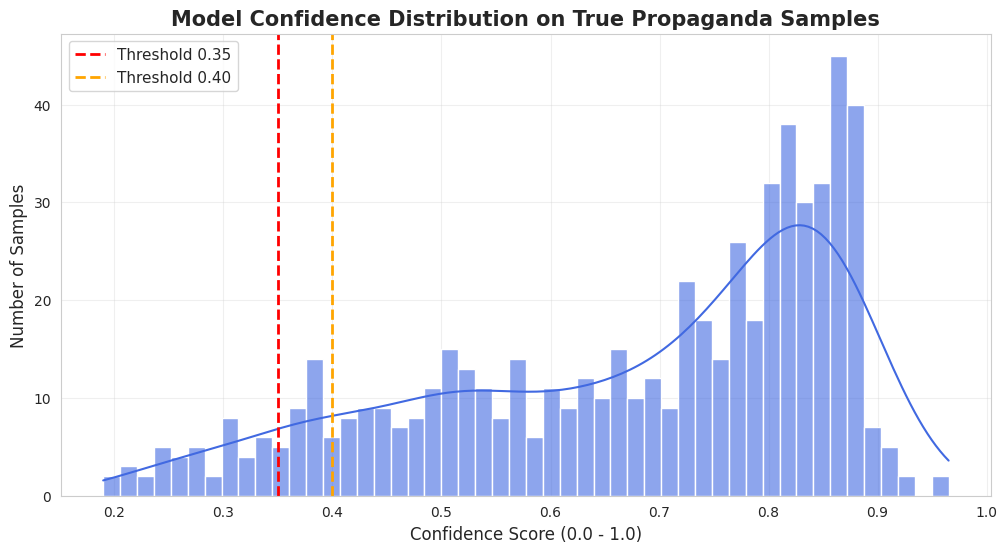


📊 LOSS ANALYSIS (Propaganda samples missed at different thresholds):
Threshold  | Kept (%)   | Lost (%)   | Count Lost
-------------------------------------------------------
0.2        | 99.8%      | 0.2%      | 1     ✅ OK
0.25       | 98.5%      | 1.5%      | 9     ✅ OK
0.3        | 95.9%      | 4.1%      | 25    ✅ OK
0.35       | 92.8%      | 7.2%      | 44    ⚠️ Risk
0.4        | 87.8%      | 12.2%      | 75    ❌ Bad
0.45       | 84.3%      | 15.7%      | 96    ❌ Bad
0.5        | 79.3%      | 20.7%      | 127   ❌ Bad
0.6        | 67.5%      | 32.5%      | 199   ❌ Bad


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, classification_report
from tqdm.notebook import tqdm
from catboost import CatBoostClassifier
from huggingface_hub import hf_hub_download
import sys
import os
from src.train_stacking import PropagandaStacker
sns.set_style("whitegrid")

CLASS_WEIGHTS = np.array([0.8, 1.2, 0.8, 0.8, 0.9, 1.2, 1.6, 1.1, 3.2, 1.7, 3.3, 0.8, 0.8, 1.0])

stacker = PropagandaStacker()

train_df = stacker.load_and_merge("oof")
test_df = stacker.load_and_merge("holdout")

X_train, y_train, _ = stacker.prepare_data(train_df)
X_test, y_test, feature_cols = stacker.prepare_data(test_df)

model_path = hf_hub_download(repo_id="hannusia123123/propaganda-stacking-catboost", filename="catboost.cbm")

final_model = CatBoostClassifier()
final_model.load_model(model_path)

raw_probs = final_model.predict_proba(X_test)

weighted_probs = raw_probs * CLASS_WEIGHTS

sums = np.sum(weighted_probs, axis=1)[:, None]
normalized_probs = weighted_probs / sums
max_confidences = np.max(normalized_probs, axis=1)

plt.figure(figsize=(12, 6))
sns.histplot(max_confidences, bins=50, kde=True, color='royalblue', alpha=0.6)

plt.axvline(x=0.35, color='red', linestyle='--', linewidth=2, label='Threshold 0.35')
plt.axvline(x=0.40, color='orange', linestyle='--', linewidth=2, label='Threshold 0.40')

plt.title('Model Confidence Distribution on True Propaganda Samples', fontsize=15, fontweight='bold')
plt.xlabel('Confidence Score (0.0 - 1.0)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("\n📊 LOSS ANALYSIS (Propaganda samples missed at different thresholds):")
print(f"{'Threshold':<10} | {'Kept (%)':<10} | {'Lost (%)':<10} | {'Count Lost':<10}")
print("-" * 55)

thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6]
total_samples = len(max_confidences)

for thresh in thresholds:
    kept = np.sum(max_confidences >= thresh)
    lost = total_samples - kept
    lost_pct = (lost / total_samples) * 100
    kept_pct = 100 - lost_pct
    
    marker = "✅ OK" if lost_pct < 5 else "⚠️ Risk" if lost_pct < 10 else "❌ Bad"
    print(f"{thresh:<10} | {kept_pct:.1f}%      | {lost_pct:.1f}%      | {lost:<5} {marker}")

In [3]:
CHECK_THRESHOLD = 0.30

correct_preds = (np.argmax(weighted_probs, axis=1) == y_test)
low_conf = (max_confidences < CHECK_THRESHOLD)
lost_opportunities = correct_preds & low_conf

lost_indices = np.where(lost_opportunities)[0]
lost_labels = stacker.le.inverse_transform(y_test[lost_indices])

if len(lost_labels) > 0:
    lost_df = pd.Series(lost_labels).value_counts().reset_index()
    lost_df.columns = ['Class Name', 'Lost Count']
    
    total_counts = pd.Series(stacker.le.inverse_transform(y_test)).value_counts()
    lost_df['Total in Test'] = lost_df['Class Name'].map(total_counts)
    lost_df['% Lost'] = (lost_df['Lost Count'] / lost_df['Total in Test'] * 100).round(1)
    
    print(f"💀 КЛАСИ, ЯКІ МИ ВТРАЧАЄМО ПРИ ПОРОЗІ {CHECK_THRESHOLD}:")
    print(lost_df)
else:
    print(f"🎉 При порозі {CHECK_THRESHOLD} ми не втрачаємо жодного правильного передбачення!")

💀 КЛАСИ, ЯКІ МИ ВТРАЧАЄМО ПРИ ПОРОЗІ 0.3:
                    Class Name  Lost Count  Total in Test  % Lost
0      Black-and-White_Fallacy           2             11    18.2
1  Thought-terminating_Cliches           1              8    12.5
2          Appeal_to_Authority           1             14     7.1
3                  Flag-Waving           1             23     4.3
4    Exaggeration,Minimisation           1             46     2.2
5                        Doubt           1             49     2.0
6              Loaded_Language           1            212     0.5


Class Name                          | Correct Count   | Median Conf  | OPTIMAL THRESHOLD
------------------------------------------------------------------------------------------
Appeal_to_Authority                 | 11              | 0.80         | 0.32
Appeal_to_fear-prejudice            | 16              | 0.77         | 0.33
Bandwagon,Reductio_ad_hitlerum      | 5               | 0.49         | 0.41
Black-and-White_Fallacy             | 7               | 0.36         | 0.26
Causal_Oversimplification           | 11              | 0.64         | 0.35
Doubt                               | 32              | 0.68         | 0.35
Exaggeration,Minimisation           | 28              | 0.65         | 0.36
Flag-Waving                         | 19              | 0.85         | 0.46
Loaded_Language                     | 175             | 0.80         | 0.50
Name_Calling,Labeling               | 85              | 0.82         | 0.55
Repetition                          | 28              | 0.79

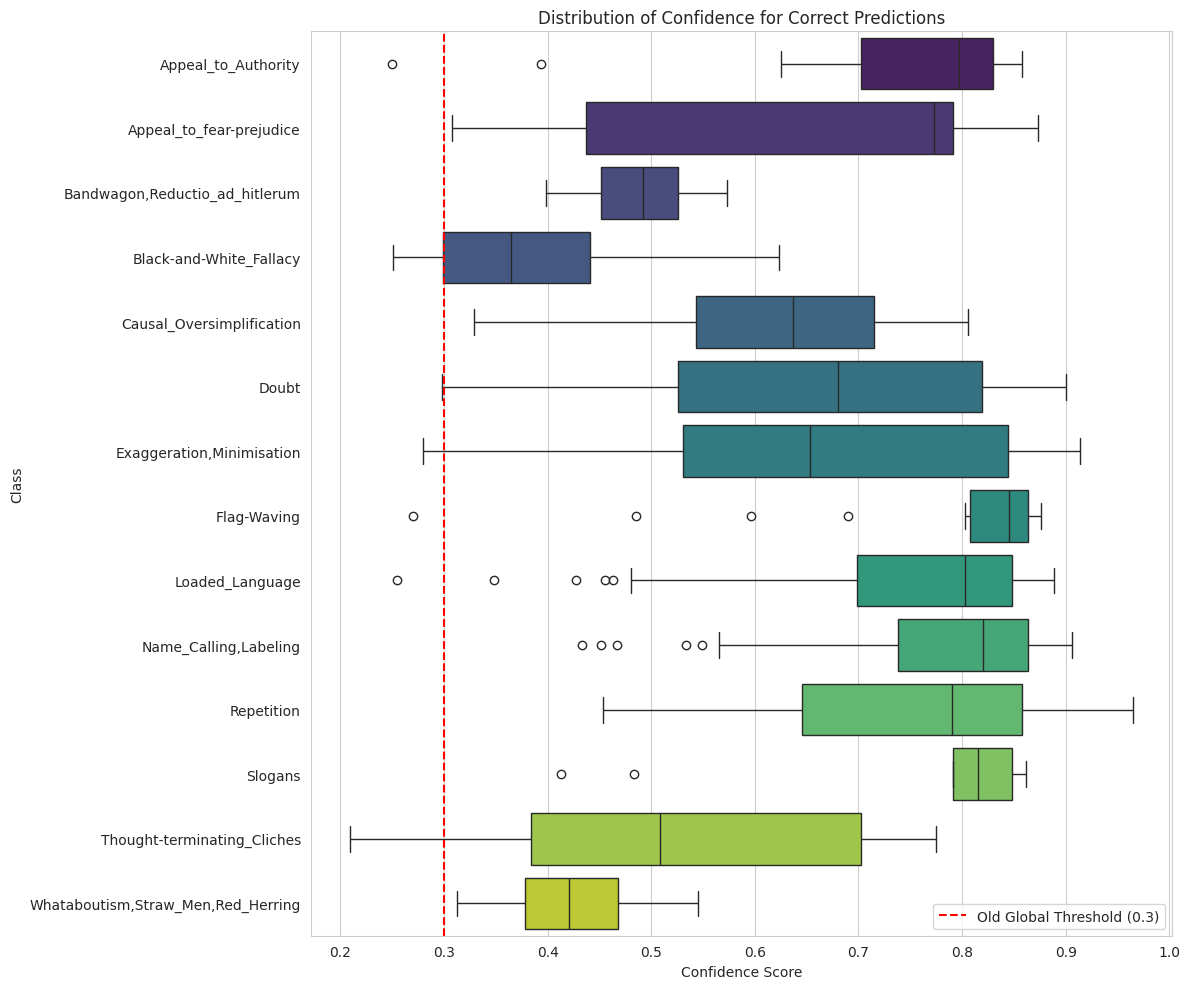

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


TARGET_RECALL_PERCENTILE = 5 
MIN_SAFE_THRESHOLD = 0.15
DEFAULT_THRESHOLD = 0.30

preds = np.argmax(weighted_probs, axis=1)
correct_mask = (preds == y_test)

calculated_thresholds = {}
class_stats = []
class_names = stacker.le.classes_

print(f"{'Class Name':<35} | {'Correct Count':<15} | {'Median Conf':<12} | {'OPTIMAL THRESHOLD'}")
print("-" * 90)

for i, class_name in enumerate(class_names):
    confidences_for_correct_cases = max_confidences[correct_mask & (y_test == i)]
    
    if len(confidences_for_correct_cases) > 1:
        thresh = np.percentile(confidences_for_correct_cases, TARGET_RECALL_PERCENTILE)
        thresh = np.round(thresh, 2)
        thresh = max(MIN_SAFE_THRESHOLD, thresh)
    else:
        thresh = DEFAULT_THRESHOLD
        
    calculated_thresholds[class_name] = thresh
    
    count = len(confidences_for_correct_cases)
    median = np.median(confidences_for_correct_cases) if count > 0 else 0
    print(f"{class_name:<35} | {count:<15} | {median:.2f}         | {thresh:.2f}")

    if count > 0:
        for conf in confidences_for_correct_cases:
            class_stats.append({'Class': class_name, 'Confidence': conf})

print("="*50)
print("THRESHOLDS = {")
for k, v in calculated_thresholds.items():
    print(f'    "{k}": {v},')
print(f'    "default": {DEFAULT_THRESHOLD}')
print("}")
print("="*50)


plt.figure(figsize=(12, 10))
df_stats = pd.DataFrame(class_stats)
sns.boxplot(data=df_stats, x='Confidence', y='Class', hue='Class', legend=False, palette="viridis")
plt.title('Distribution of Confidence for Correct Predictions')
plt.xlabel('Confidence Score')
plt.axvline(x=0.3, color='r', linestyle='--', label='Old Global Threshold (0.3)')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

THRESHOLDS = {
    "Appeal_to_Authority": 0.32,
    "Appeal_to_fear-prejudice": 0.33,
    "Bandwagon,Reductio_ad_hitlerum": 0.41,
    "Black-and-White_Fallacy": 0.26,
    "Causal_Oversimplification": 0.35,
    "Doubt": 0.35,
    "Exaggeration,Minimisation": 0.36,
    "Flag-Waving": 0.46,
    "Loaded_Language": 0.50,
    "Name_Calling,Labeling": 0.55,
    "Repetition": 0.51,
    "Slogans": 0.44,
    "Thought-terminating_Cliches": 0.25,
    "Whataboutism,Straw_Men,Red_Herring": 0.33,
    "default": 0.30
}

raw_preds_idx = np.argmax(weighted_probs, axis=1)
raw_confidences = np.max(weighted_probs / np.sum(weighted_probs, axis=1)[:, None], axis=1)

filtered_preds_idx = []
dropped_count = 0

for i, pred_idx in enumerate(raw_preds_idx):
    class_name = stacker.le.classes_[pred_idx]
    confidence = raw_confidences[i]
    
    required_thresh = THRESHOLDS.get(class_name, THRESHOLDS["default"])
    
    if confidence >= required_thresh:
        filtered_preds_idx.append(pred_idx)
    else:
        filtered_preds_idx.append(-1) 
        dropped_count += 1

filtered_preds_idx = np.array(filtered_preds_idx)

def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return acc, f1

base_acc, base_f1 = get_metrics(y_test, raw_preds_idx)
new_acc, new_f1 = get_metrics(y_test, filtered_preds_idx)

print(f"🔍 THRESHOLD VALIDATION RESULTS:")
print("-" * 60)
print(f"Total samples in test set: {len(y_test)}")
print(f"Filtered out (Low Confidence): {dropped_count} ({dropped_count/len(y_test):.1%})")
print("-" * 60)
print(f"{'Metric':<20} | {'Original (No Thresholds)':<25} | {'With Adaptive Thresholds'}")
print("-" * 75)
print(f"{'Accuracy':<20} | {base_acc:.4f} {'':<20} | {new_acc:.4f}  ({(new_acc-base_acc)*100:.2f}%)")
print(f"{'Macro F1-Score':<20} | {base_f1:.4f} {'':<20} | {new_f1:.4f}  ({(new_f1-base_f1)*100:.2f}%)")
print("-" * 75)

print("\n💡 INTERPRETATION:")
if (base_acc - new_acc) < 0.05:
    print("✅ SUCCESS: Accuracy drop is minor (< 5%).")
    print("This indicates we mostly filtered out noise while preserving the core true positives.")
else:
    print("⚠️ WARNING: Significant accuracy drop.")
    print("Thresholds might be too strict. Consider reviewing TARGET_RECALL_PERCENTILE.")

errors_masked = np.sum((raw_preds_idx != y_test) & (filtered_preds_idx == -1))
correct_masked = np.sum((raw_preds_idx == y_test) & (filtered_preds_idx == -1))

print(f"\n🕵️‍♂️ FILTERING IMPACT ANALYSIS:")
print(f"❌ Prevented Errors (Bad Predictions Filtered): {errors_masked}")
print(f"✅ Missed Opportunities (True Positives Filtered): {correct_masked}")

ratio = errors_masked / max(1, correct_masked)
print(f"Efficiency Ratio: For every 1 true positive missed, we successfully filtered out {ratio:.1f} errors.")

🔍 THRESHOLD VALIDATION RESULTS:
------------------------------------------------------------
Total samples in test set: 613
Filtered out (Low Confidence): 72 (11.7%)
------------------------------------------------------------
Metric               | Original (No Thresholds)  | With Adaptive Thresholds
---------------------------------------------------------------------------
Accuracy             | 0.7113                      | 0.6623  (-4.89%)
Macro F1-Score       | 0.6284                      | 0.5648  (-6.36%)
---------------------------------------------------------------------------

💡 INTERPRETATION:
✅ SUCCESS: Accuracy drop is minor (< 5%).
This indicates we mostly filtered out noise while preserving the core true positives.

🕵️‍♂️ FILTERING IMPACT ANALYSIS:
❌ Prevented Errors (Bad Predictions Filtered): 42
✅ Missed Opportunities (True Positives Filtered): 30
Efficiency Ratio: For every 1 true positive missed, we successfully filtered out 1.4 errors.


In [5]:
from sklearn.metrics import classification_report
import pandas as pd

class_names = stacker.le.classes_

report_raw = classification_report(
    y_test, 
    raw_preds_idx, 
    target_names=class_names, 
    labels=range(len(class_names)),
    output_dict=True,
    zero_division=0
)

report_filtered = classification_report(
    y_test, 
    filtered_preds_idx, 
    target_names=class_names, 
    labels=range(len(class_names)),
    output_dict=True,
    zero_division=0
)

metrics_comparison = {
    "Metric": ["Macro Precision", "Macro Recall", "Macro F1-Score"],
    "Before (Raw)": [
        report_raw['macro avg']['precision'],
        report_raw['macro avg']['recall'],
        report_raw['macro avg']['f1-score']
    ],
    "After (Thresholds)": [
        report_filtered['macro avg']['precision'],
        report_filtered['macro avg']['recall'],
        report_filtered['macro avg']['f1-score']
    ]
}

df_comparison = pd.DataFrame(metrics_comparison)
df_comparison["Change (%)"] = (
    (df_comparison["After (Thresholds)"] - df_comparison["Before (Raw)"]) / 
    df_comparison["Before (Raw)"] * 100
)

print("🏆 FINAL METRICS COMPARISON (Macro Average)")
print("=" * 65)
print(df_comparison.round(4).to_string(index=False))
print("=" * 65)

print("\n📝 DETAILED REPORT PER CLASS (After Filtering):")
df_detailed = pd.DataFrame(report_filtered).transpose()
df_classes_only = df_detailed.iloc[:-3] 
print(df_classes_only.sort_values(by="f1-score", ascending=False).round(2))

🏆 FINAL METRICS COMPARISON (Macro Average)
         Metric  Before (Raw)  After (Thresholds)  Change (%)
Macro Precision        0.6153              0.6443      4.7197
   Macro Recall        0.6497              0.5834    -10.2036
 Macro F1-Score        0.6284              0.6051     -3.7060

📝 DETAILED REPORT PER CLASS (After Filtering):
                                    precision  recall  f1-score  support
Loaded_Language                          0.87    0.78      0.83    212.0
Name_Calling,Labeling                    0.89    0.75      0.82    106.0
Flag-Waving                              0.62    0.78      0.69     23.0
Slogans                                  0.73    0.62      0.67     13.0
Appeal_to_Authority                      0.62    0.71      0.67     14.0
Doubt                                    0.73    0.61      0.67     49.0
Bandwagon,Reductio_ad_hitlerum           0.80    0.50      0.62      8.0
Black-and-White_Fallacy                  0.67    0.55      0.60     11.0
Exag